In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Polygon
from matplotlib.colors import LinearSegmentedColormap


In [2]:
# GRID AND PHYSICAL PARAMETERS
Nx, Ny = 160, 90
Sx, Sy = Nx + 2, Ny + 2

# Triangle size
D = 14.0

# Position of triangle
cx = 40.0
cy_steady = Ny / 2 + 1.0
cy_unstable = Ny / 2 + 2.0

U_in = 1.0
dt = 0.5

GS_ITERS = 26

FRAME_INTERVAL = 10
N_STEPS = 650

OUT_GIF = "steady_vs_unstable_triangle.gif"

# GRID
xx, yy = np.meshgrid(np.arange(Sx),np.arange(Sy),indexing='ij')

In [3]:
# TRIANGLE GEOMETRY

def triangle_vertices(cx, cy, D):
    height = D

    vertices = np.array([[cx - D / 2, cy - height / 2],[cx - D / 2, cy + height / 2],[cx + D / 2, cy]])
    return vertices

# CREATE TRIANGULAR MASK

def make_triangle_mask(cx, cy, D):

    vertices = triangle_vertices(cx, cy, D)

    x1, y1 = vertices[0]
    x2, y2 = vertices[1]
    x3, y3 = vertices[2]

    # Barycentric-coordinate method

    denominator = ((y2 - y3) * (x1 - x3)+ (x3 - x2) * (y1 - y3))

    a = ((y2 - y3) * (xx - x3)+ (x3 - x2) * (yy - y3)) / denominator
    b = ((y3 - y1) * (xx - x3)+ (x1 - x3) * (yy - y3)) / denominator
    c = 1.0 - a - b

    mask = ((a >= 0) & (b >= 0) & (c >= 0))

    return mask

In [4]:
# VELOCITY BOUNDARY CONDITIONS
def set_boun_vel(u, v):

    u[0, :] = U_in
    v[0, :] = 0.0

    u[-1, :] = u[-2, :]
    v[-1, :] = v[-2, :]

    v[:, 0] = 0.0
    v[:, -1] = 0.0

    u[:, 0] = u[:, 1]
    u[:, -1] = u[:, -2]

# PRESSURE BOUNDARY CONDITIONS

def set_boun_pressure(p):

    p[0, :] = p[1, :]
    p[-1, :] = 0.0

    p[:, 0] = p[:, 1]
    p[:, -1] = p[:, -2]

In [5]:
# DIFFUSION
def diffuse_component(x,x0,diff_rate,dt,is_u,iters=GS_ITERS):

    a = dt * diff_rate

    c_inv = 1.0 / (1 + 4 * a)

    for _ in range(iters):

        x[1:-1, 1:-1] = (x0[1:-1, 1:-1] + a * ( x[0:-2, 1:-1] + x[2:, 1:-1] + x[1:-1, 0:-2] + x[1:-1, 2:])) * c_inv

        if is_u:

            x[0, :] = U_in
            x[-1, :] = x[-2, :]

            x[:, 0] = x[:, 1]
            x[:, -1] = x[:, -2]

        else:

            x[0, :] = 0.0
            x[-1, :] = x[-2, :]

            x[:, 0] = 0.0
            x[:, -1] = 0.0

    return x



In [6]:
# ADVECTION
def advect(d, d0, u, v, dt, is_u):

    Xg, Yg = np.meshgrid(np.arange(1, Nx + 1),np.arange(1, Ny + 1),indexing='ij')

    x = Xg - dt * u[1:-1, 1:-1]
    y = Yg - dt * v[1:-1, 1:-1]

    x = np.clip(x, 0.5, Nx + 0.5)
    y = np.clip(y, 0.5, Ny + 0.5)

    i0 = x.astype(int)
    i1 = i0 + 1

    j0 = y.astype(int)
    j1 = j0 + 1

    s1 = x - i0
    s0 = 1 - s1

    t1 = y - j0
    t0 = 1 - t1

    d[1:-1, 1:-1] = ( s0 * ( t0 * d0[i0, j0] + t1 * d0[i0, j1]) + s1 * (t0 * d0[i1, j0] + t1 * d0[i1, j1]))

    if is_u:

        d[0, :] = U_in
        d[-1, :] = d[-2, :]

        d[:, 0] = d[:, 1]
        d[:, -1] = d[:, -2]

    else:

        d[0, :] = 0.0
        d[-1, :] = d[-2, :]

        d[:, 0] = 0.0
        d[:, -1] = 0.0

    return d


In [7]:
# PRESSURE PROJECTION

def project(u, v, p, div):

    div[1:-1, 1:-1] = (-0.5 * ( u[2:, 1:-1] - u[0:-2, 1:-1] + v[1:-1, 2:] - v[1:-1, 0:-2]))

    p[:] = 0

    set_boun_pressure(div)
    set_boun_pressure(p)

    for _ in range(GS_ITERS):

        p[1:-1, 1:-1] = ( div[1:-1, 1:-1] + p[0:-2, 1:-1] + p[2:, 1:-1] + p[1:-1, 0:-2] + p[1:-1, 2:]) / 4.0

        set_boun_pressure(p)

    u[1:-1, 1:-1] -= ( 0.5 * (p[2:, 1:-1] - p[0:-2, 1:-1]))

    v[1:-1, 1:-1] -= (0.5 * (p[1:-1, 2:] - p[1:-1, 0:-2]))

    set_boun_vel(u, v)

    return u, v


running steady (low Re) case...
running unstable (high Re) case...
rendering 65 frames...
saved: steady_vs_unstable_triangle.gif


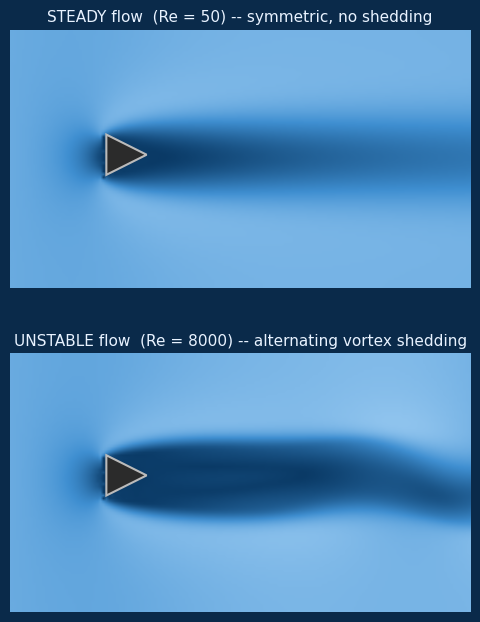

In [12]:
# RUN ONE CASE
def run_case(Re,cy,seed,n_steps,frame_interval):
    nu = U_in * D / Re
    # TRIANGLE OBSTACLE

    mask = make_triangle_mask(cx,cy,D)
    # INITIAL VELOCITY

    u = np.full((Sx, Sy),U_in)

    v = np.zeros((Sx, Sy))

    # No flow inside triangle
    u[mask] = 0.0
    v[mask] = 0.0

    frames = []
    # TIME LOOP
    
    for step in range(n_steps):

        u0 = u.copy()     # Diffusion
        v0 = v.copy()

        diffuse_component(u,u0,nu,dt,True)

        diffuse_component(v,v0,nu,dt,False)
        
        # PRESSURE PROJECTION

        p = np.zeros((Sx, Sy))

        div = np.zeros((Sx, Sy))

        project(u,v,p,div)

        # Triangle no-slip condition
        u[mask] = 0.0
        v[mask] = 0.0

        
        u0 = u.copy()    # advection
        v0 = v.copy()

        advect(u,u0,u0,v0,dt,True)

        advect(v,v0,u0,v0,dt,False)

        
        project(u,v,p,div)   # Second pressure projection

        # Triangle no-slip condition
        u[mask] = 0.0
        v[mask] = 0.0

        if seed and step < 8:

            v[int(cx) + 3:int(cx) + 8,Ny // 2:Ny // 2 + 2] += 0.3   # Perturbation for unstable case
        if step % frame_interval == 0:

            speed = np.sqrt(u[1:-1, 1:-1] ** 2 + v[1:-1, 1:-1] ** 2)
            frames.append(speed.copy())

    return frames


print("running steady (low Re) case...")

frames_steady = run_case(
    Re=50,
    cy=cy_steady,
    seed=False,
    n_steps=N_STEPS,
    frame_interval=FRAME_INTERVAL)


print("running unstable (high Re) case...")

frames_unstable = run_case(
    Re=8000,
    cy=cy_unstable,
    seed=True,
    n_steps=N_STEPS,
    frame_interval=FRAME_INTERVAL)


n_frames = min(len(frames_steady),len(frames_unstable))

print(f"rendering {n_frames} frames...")

water_cmap = LinearSegmentedColormap.from_list("plain_water",["#0a3a66","#3f8fd1","#bfe3ff"])
# FIGURE

fig, axes = plt.subplots(2,1,figsize=(9, 6.4),facecolor="#0a2a4a")
def draw_triangle(ax, cy):

    vertices = triangle_vertices(cx,cy,D)

    triangle_patch = Polygon(vertices,closed=True,facecolor="#2b2b2b",edgecolor="#bbbbbb",linewidth=1.5,zorder=3)

    ax.add_patch(triangle_patch)


axes[0].set_facecolor("#0a2a4a")
axes[0].axis("off")

axes[0].set_title("STEADY flow  (Re = 50) -- symmetric, no shedding",color="#e8f2ff",fontsize=11)

im1 = axes[0].imshow(np.transpose(frames_steady[0],(1, 0)),origin="lower",cmap=water_cmap,vmin=0,vmax=1.5,interpolation="bilinear")

draw_triangle(axes[0],cy_steady)

axes[1].set_facecolor("#0a2a4a")
axes[1].axis("off")

axes[1].set_title("UNSTABLE flow  (Re = 8000) -- alternating vortex shedding",color="#e8f2ff",fontsize=11)

im2 = axes[1].imshow(np.transpose(frames_unstable[0],(1, 0)),origin="lower",cmap=water_cmap,vmin=0,vmax=1.5,interpolation="bilinear")

draw_triangle(axes[1],cy_unstable)
fig.subplots_adjust(left=0.02,right=0.98,top=0.93,bottom=0.02,hspace=0.25)

def update(i):

    im1.set_data(np.transpose(frames_steady[i],(1, 0)))

    im2.set_data(np.transpose(frames_unstable[i],(1, 0)))

    return im1, im2

anim = animation.FuncAnimation(fig,update,frames=n_frames,blit=True)
anim.save(OUT_GIF,writer=animation.PillowWriter(fps=20),dpi=120,savefig_kwargs={"facecolor": fig.get_facecolor()})
print("saved:", OUT_GIF)